Saved: function_1_plot.png


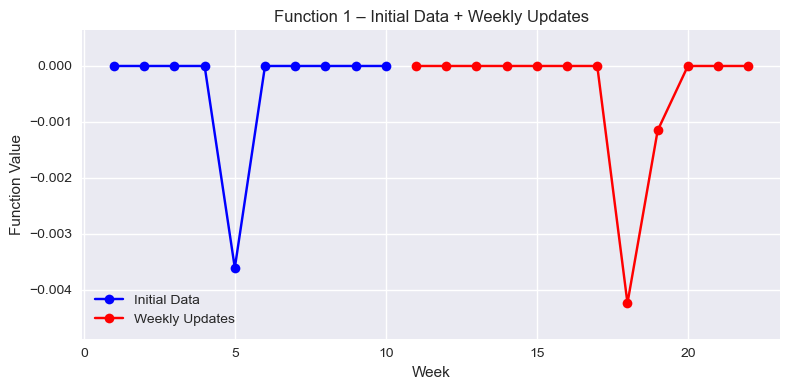

Saved: function_2_plot.png


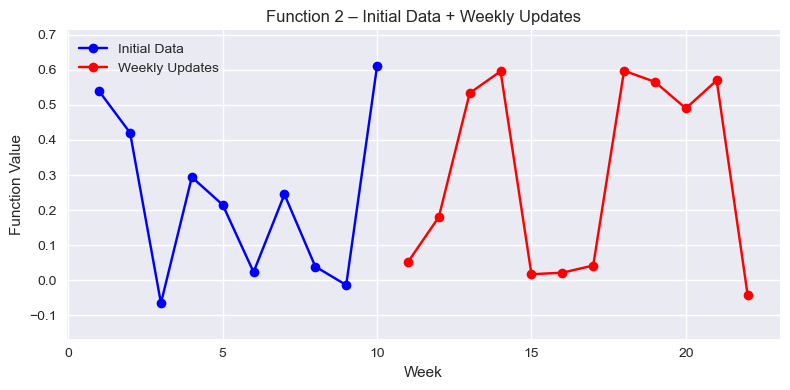

Saved: function_3_plot.png


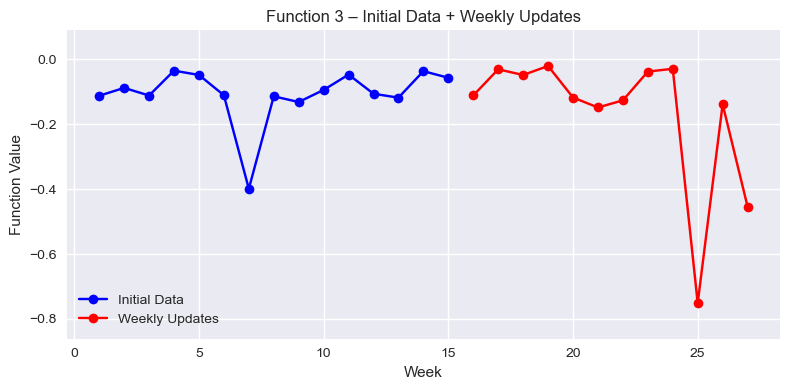

Saved: function_4_plot.png


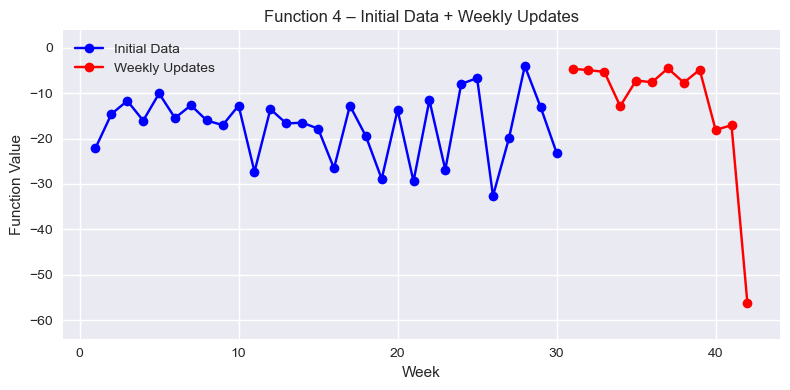

Saved: function_5_plot.png


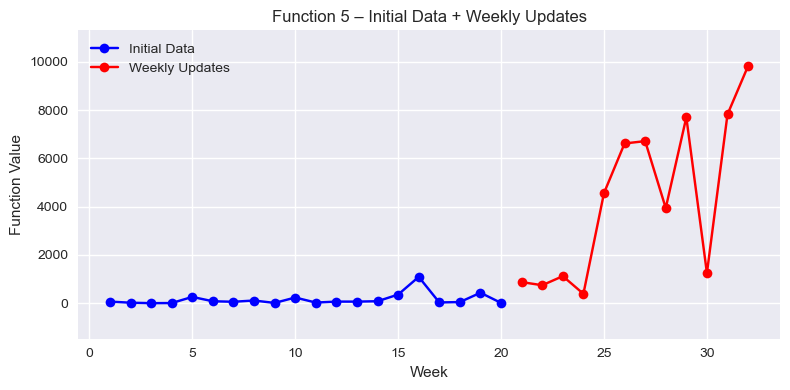

Saved: function_6_plot.png


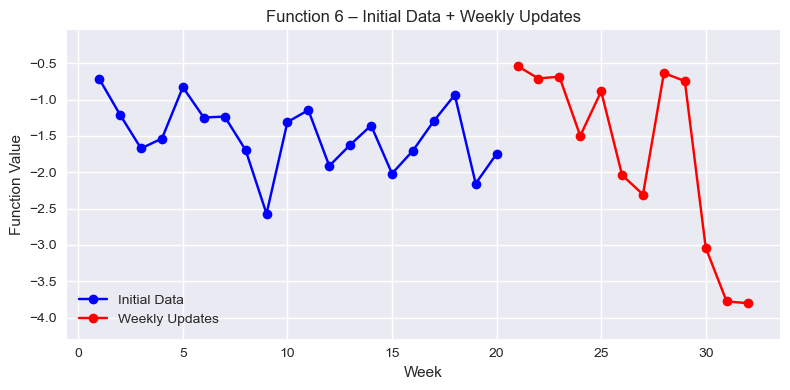

Saved: function_7_plot.png


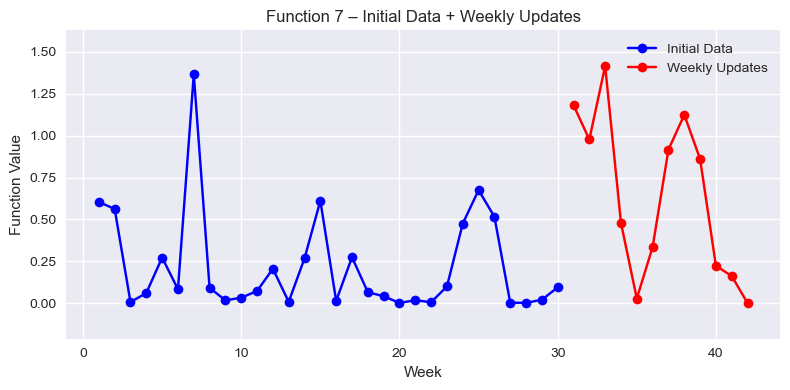

Saved: function_8_plot.png


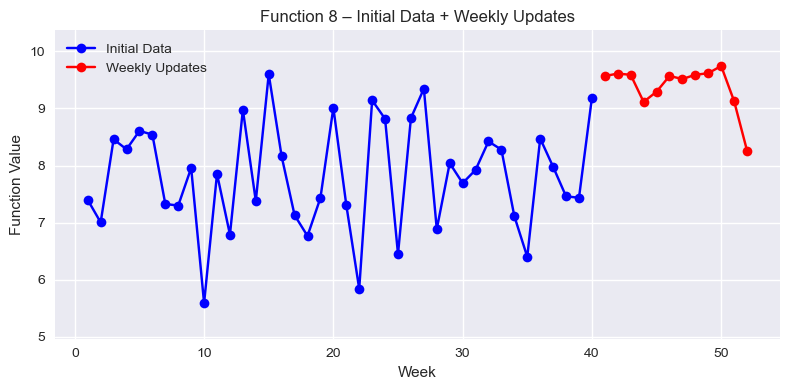

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Ensure parent directory is on path
sys.path.append(os.path.abspath(".."))

# Import all handlers
from function_1.Function1DataHandler import Function1DataHandler
from function_2.Function2DataHandler import Function2DataHandler
from function_3.Function3DataHandler import Function3DataHandler
from function_4.Function4DataHandler import Function4DataHandler
from function_5.Function5DataHandler import Function5DataHandler
from function_6.Function6DataHandler import Function6DataHandler
from function_7.Function7DataHandler import Function7DataHandler
from function_8.Function8DataHandler import Function8DataHandler

# ---------------------------------------------------------
# Create handlers in order
# ---------------------------------------------------------
handlers = [
    Function1DataHandler(),
    Function2DataHandler(),
    Function3DataHandler(),
    Function4DataHandler(),
    Function5DataHandler(),
    Function6DataHandler(),
    Function7DataHandler(),
    Function8DataHandler(),
]

# ---------------------------------------------------------
# Plot each function with original vs weekly updates
# ---------------------------------------------------------
plt.style.use("seaborn-v0_8")

for i, handler in enumerate(handlers, start=1):

    # -----------------------------------------
    # 1. Capture original data (constructor-loaded)
    # -----------------------------------------
    original_outputs = np.array(handler.get_outputs(), dtype=float)
    original_len = len(original_outputs)

    # -----------------------------------------
    # 2. Apply weekly updates
    # -----------------------------------------
    handler.add_weekly_updates()
    updated_outputs = np.array(handler.get_outputs(), dtype=float)

    # -----------------------------------------
    # 3. Build x-axis
    # -----------------------------------------
    weeks = np.arange(1, len(updated_outputs) + 1)

    # -----------------------------------------
    # 4. Split into old vs new
    # -----------------------------------------
    old_x = weeks[:original_len]
    old_y = updated_outputs[:original_len]

    new_x = weeks[original_len:]
    new_y = updated_outputs[original_len:]

    # -----------------------------------------
    # 5. Plot
    # -----------------------------------------
    plt.figure(figsize=(8, 4))

    # Original points (constructor-loaded)
    plt.plot(old_x, old_y, marker='o', color='blue', label='Initial Data')

    # Newly added points (via add_weekly_updates)
    if len(new_y) > 0:
        plt.plot(new_x, new_y, marker='o', color='red', label='Weekly Updates')

    # Auto-scale y-axis
    ymin, ymax = updated_outputs.min(), updated_outputs.max()
    margin = (ymax - ymin) * 0.15 if ymax != ymin else 1
    plt.ylim(ymin - margin, ymax + margin)

    plt.title(f"Function {i} – Initial Data + Weekly Updates")
    plt.xlabel("Week")
    plt.ylabel("Function Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    filename = f"function_{i}_plot.png"
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")

    plt.show()